# TVJT vs. the plain LLM judge — repaired world-truth checks lose on held-out NL→FOL items

**Artifact:** `art_sXkKbn1vj6ZX` (experiment, iter 2) — *Repaired world-truth checks lose to the plain judge*

**The question.** Given only a sentence and a candidate first-order-logic (FOL) formula (no gold formula), can we predict whether the formula is *faithful* to the sentence?

**TVJT (Truth-Value Judgement Test).** For a candidate formula **F**, z3 builds typed *mutants* of F (negation, quantifier flip, implication reversal, dropped/added conjunct, argument swap, ∧/∨ swap, scope swap, merge, cardinality). For each mutant it finds a **minimal finite world** (≤4 individuals) where F and the mutant disagree. Each world is verbalised in English. An LLM judge (gemini-2.5-flash) sees the **sentence only, never the formula**, and says whether the sentence is TRUE or FALSE in each world, with a confidence. TVJT then scores how often the sentence's judged truth value agrees with F's truth value in those worlds:

* **C1**: vote-0 binary agreement
* **C2**: 3-vote majority agreement
* **C3** (frozen primary): mean confidence-weighted probability that the sentence has F's truth value

**The baseline, B1.** A fixed-prompt LLM judge (same gemini-2.5-flash) is shown the sentence and the FOL and asked *"probability (0-100) that this FOL is faithful"*.

**What happened in the full run.** Phase 1 repaired TVJT: canonical name-blind normal form, deterministic worlds, a world-level answer cache, 3 order-permuted votes and confidence weighting. After the repair, logically equivalent rewrites produce identical worlds. On the pre-registered held-out panel (609 items, top tercile P-top n = 389), TVJT\* scored AUROC_w **.665** against B1 **.749**. The H1 difference Δ(TVJT\*−B1) on P-top was **−.098 [−.184, −.014]**, so the verdict is **REVERSED**: B1 wins.

**What this notebook does.** It runs the scoring and analysis parts of the pipeline **offline** on a curated subset of 97 top-tercile panel items (35 sentences, 9 generator systems):
1. It uses the frozen TVJT judge protocol (`judge.py`: prompt, order permutations, parsing, world-level cache, `score_tvjt`). Each item's canonical worlds and the **cached** gemini-2.5-flash answers ship with the data, so the replay makes no API calls and costs $0.
2. It checks that the replayed C3 equals the artifact's `predict_TVJT_frozen`.
3. It runs the Phase-2 analysis (`analysis2.py`): post-stratified weighted AUROC, a paired sentence-cluster bootstrap for Δ(TVJT\*−B1), and within-sentence pairwise accuracy. The metrics compared are TVJT\*, B1, B1×3, LC_onecoin, A3 and iter-1 TVJT.

## 1. Setup

Most of the pipeline is plain Python. The artifact's scoring and analysis code needs `numpy` and `pandas`, and the plots need `matplotlib`. All three are pre-installed on Colab, so they are installed locally only, at Colab's versions.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only (Colab-matched versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


### Imports
These are the import blocks of `src/judge.py` and `src/analysis2.py`. `loguru` and `aiohttp` were only used for logging and the live OpenRouter backend, so they are left out here. `matplotlib` is added for the final plots.

In [2]:
from __future__ import annotations

import asyncio
import collections as C
import hashlib
import json
import math
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Data loading
`mini_demo_data.json` is a curated subset of the artifact's `heldout_panel` (from `full_method_out.json`). Each item carries:
* the sentence, the raw candidate FOL and its FOLIO-syntax bridge (`fol_folio`)
* the panel3 label (`output` = faithful/unfaithful) and its post-stratification weight
* the artifact's stored predictions (`predict_*`)
* the item's **canonical TVJT worlds** (from `data/worlds_canon.jsonl`), each with `text`, `F_value` and `op`, plus the **cached gemini-2.5-flash answers** `[v, conf]` for votes 0..2 (from `cache/judge_worlds__google_gemini-2.5-flash__main.jsonl`)

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-abf543-do-sentence-and-formula-generalize-the/main/round-2/experiment-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["source"])
print("items:", data["n"], "| sentences:", len({e["metadata_sentence_id"] for e in data["examples"]}))
ex0 = data["examples"][0]
print("\nexample sentence :", ex0["sentence"])
print("candidate FOL    :", ex0["fol_raw"])
print("label            :", ex0["output"], "| system:", ex0["metadata_system"])
print("n canonical worlds:", len(ex0["worlds"]))

art_sXkKbn1vj6ZX full_method_out.json :: heldout_panel (+ data/worlds_canon.jsonl, cache/judge_worlds__google_gemini-2.5-flash__main.jsonl)
items: 97 | sentences: 35

example sentence : A building has either an elevator or stairs, but not both.
candidate FOL    : ∀b (Building(b) → (∃e (Elevator(e) ∧ Has(b,e)) ⊕ ∃s (Stairs(s) ∧ Has(b,s))))
label            : faithful | system: deepseek-v3.1
n canonical worlds: 2


## 2. Configuration

These are all the tunable parameters. The original values are in the comments.
* `N_ITEMS`: how many curated panel items to score (the original used all 609 panel items and 389 in P-top)
* `VOTES`: order-permuted judge votes per world (frozen protocol: 3)
* `N_BOOT`: sentence-cluster bootstrap resamples (original: 2000)
* `SEED`: bootstrap seed (original: 0)

In [5]:
N_ITEMS = 97      # curated subset size (original: 609 panel items / 389 in P-top)
VOTES = 3         # frozen protocol: 3 order-permuted votes per world
N_BOOT = 2000     # original: N_BOOT = 2000 sentence-cluster bootstrap resamples
SEED = 0          # original bootstrap seed

## 3. The orchestrator (`method.py`), for reference

`method.py` in the artifact is a thin stage runner. Each stage shells out to a script in `src/`:

```
canon_diag     R1 canonical worlds for the screen + zero-cost diagnostics
targets        label-blind held-out target table + syntax bridge coverage
worlds         canonical worlds for held-out P ∪ Ccon ∪ top-tercile T     (z3, CPU-heavy: minutes-hours)
zero_llm       LC_onecoin + B3sc + LC on contamination + A3 signature
freeze         frozen_config.json + prereg.json → freeze_receipt.json
score_heldout  TVJT* / B1 / B1x3 with gemini-2.5-flash                   (paid, OpenRouter)
analysis       results/analysis.json + verdict.json
export         method_out.json
```

This notebook skips the expensive stages. The **worlds** stage needs z3 plus about 2k lines of FOL/mutant/verbaliser code, and **score_heldout** makes paid API calls. Their outputs ship inside `mini_demo_data.json`. The notebook runs the **score_heldout** logic as a cache replay and the **analysis** logic in full.

## 4. Shared helpers (`src/common.py`)
These are the hashing and JSONL helpers used by the caches. `CACHE` points at a local `cache/` folder instead of the artifact root.

In [6]:
CACHE = Path("cache")
CACHE.mkdir(parents=True, exist_ok=True)


def sha1(s: str) -> str:
    return hashlib.sha1(s.encode()).hexdigest()


def read_jsonl(p: Path) -> list[dict]:
    if not Path(p).exists():
        return []
    out = []
    with open(p) as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    out.append(json.loads(line))
                except json.JSONDecodeError:
                    continue
    return out


def append_jsonl(p: Path, rows: list[dict]) -> None:
    with open(p, "a") as f:
        for r in rows:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

## 5. The frozen TVJT judge protocol (`src/judge.py`, R2 + R3)

This cell is copied unchanged from `judge.py`:
* **Prompt** `TVJT_V2`: the judge sees the sentence and numbered *situations* (verbalised worlds), never the formula. It returns `{"i": [v, confidence]}`.
* **`perm`**: vote k presents the worlds in canonical order (k=0), reversed (k=1) or rotated by ⌈n/2⌉ (k=2). This cancels position bias.
* **`WorldCache`**: a world-level answer cache keyed by `sha1(model | prompt_version | sentence | world_text | vote)`. The iter-1 judge gave different verdicts to identical (sentence, world) pairs 13.7% of the time. This cache makes every answer deterministic and reusable.
* **`judge_target`**: sends only the uncached worlds, in one batched call per vote.
* **`score_tvjt`**: computes C1/C2/C3 and guesses the error type. The guess is the mutant family whose worlds disagree most.

`OPERATORS` is copied from `third_party/armB/src/mutants.py`. `score_tvjt` imported it with `from mutants import OPERATORS`.

In [7]:
# from third_party/armB/src/mutants.py (score_tvjt does `from mutants import OPERATORS`)
OPERATORS = ["NEG", "QUANT", "IMPL_REV", "DROP_CONJ", "ADD_CONJ", "ARG_SWAP", "AND_OR", "SCOPE_SWAP", "MERGE", "CARD"]

PROMPT_VERSION = "tvjt_v2_conf"
TVJT_V2 = ("You will read a sentence and several small, self-contained situations. For each situation, decide "
           "whether the sentence is TRUE or FALSE in that situation, using ONLY the listed individuals and facts "
           "(anything not listed is false; interpret general statements as being about the individuals listed). "
           "Sentence: \"{S}\"\n\n{SITUATIONS}\n\n"
           "Answer with JSON only, one entry per situation: {{\"1\": [v, c], ...}} where v is 1 if the sentence is "
           "TRUE in that situation and 0 if FALSE, and c is your confidence 0-100.")
B1_PROMPT = ("Sentence: {s}\nFOL: {f}\nGive the probability (0-100) that this FOL is a faithful formalization of "
             "the sentence. Reply with a number only.")
GEMINI = "google/gemini-2.5-flash"


# ------------------------------------------------------------------------------------------ prompts
def perm(n: int, k: int) -> list[int]:
    idx = list(range(n))
    if k == 0:
        return idx
    if k == 1:
        return idx[::-1]
    r = math.ceil(n / 2)
    return idx[r:] + idx[:r]


def build_tvjt_prompt(sentence: str, texts: list[str]) -> str:
    sits = "\n".join(f"Situation {i}: {t}" for i, t in enumerate(texts, 1))
    return TVJT_V2.format(S=sentence, SITUATIONS=sits)


def parse_tvjt(text: str, k: int) -> dict[int, tuple[int, float]] | None:
    m = re.search(r"\{.*\}", text or "", re.S)
    if not m:
        return None
    try:
        d = json.loads(m.group(0))
    except json.JSONDecodeError:
        return None
    out = {}
    for i in range(1, k + 1):
        v = d.get(str(i), d.get(i))
        if isinstance(v, dict):
            v = [v.get("v"), v.get("c")]
        if not isinstance(v, (list, tuple)) or len(v) < 1:
            return None
        try:
            vv = int(v[0]) if not isinstance(v[0], str) else (1 if v[0].strip().upper() in ("1", "TRUE") else 0)
            cc = float(v[1]) if len(v) > 1 and v[1] is not None else 100.0
        except (TypeError, ValueError):
            return None
        if vv not in (0, 1):
            return None
        out[i] = (vv, min(100.0, max(0.0, cc)))
    return out


# ------------------------------------------------------------------------------------------ caches
class WorldCache:
    """(backend, prompt_version, sentence, world_text, vote) → [v, c]; append-only jsonl."""

    def __init__(self, backend_name: str, namespace: str = "main"):
        safe = re.sub(r"[^A-Za-z0-9_.-]+", "_", backend_name)
        self.path = CACHE / f"judge_worlds__{safe}__{namespace}.jsonl"
        self.backend_name = backend_name
        self.d = {r["k"]: r["a"] for r in read_jsonl(self.path)}

    def key(self, sentence: str, text: str, vote: int) -> str:
        return sha1(f"{self.backend_name}|{PROMPT_VERSION}|{sentence}|{text}|{vote}")

    def get(self, sentence, text, vote):
        return self.d.get(self.key(sentence, text, vote))

    def put(self, sentence, text, vote, ans) -> None:
        k = self.key(sentence, text, vote)
        self.d[k] = ans
        append_jsonl(self.path, [{"k": k, "a": ans}])


# ------------------------------------------------------------------------------------------ TVJT
async def judge_target(be, wcache: WorldCache, sentence: str, worlds: list[dict], votes: int, stage: str,
                       item_id: str) -> dict:
    """worlds: canonical-ordered dicts with 'text', 'F_value', 'op'. Fills the world cache for votes 0..votes-1
    and returns per-world answers {vote: [[v,c]|None per world]} plus usd/seconds/malformed counts."""
    usd = sec = 0.0
    malformed = 0
    texts = [w["text"] for w in worlds]
    for k in range(votes):
        unc = [i for i, t in enumerate(texts) if wcache.get(sentence, t, k) is None]
        # dedupe identical texts inside a target (possible after name mapping)
        seen, U = set(), []
        for i in unc:
            if texts[i] not in seen:
                seen.add(texts[i])
                U.append(i)
        if not U:
            continue
        order = [U[j] for j in perm(len(U), k)]
        prompt = build_tvjt_prompt(sentence, [texts[i] for i in order])
        ans = None
        for attempt in range(2):
            p = prompt if attempt == 0 else prompt + "\nReturn ONLY the JSON object, with every key."
            r = await be.complete(p, 60 + 14 * len(order), stage, f"{item_id}:v{k}:a{attempt}")
            usd += r["usd"]
            sec += r["seconds"]
            ans = parse_tvjt(r["text"], len(order))
            if ans is not None:
                break
            malformed += 1
        if ans is None:
            continue
        for pos, i in enumerate(order, 1):
            wcache.put(sentence, texts[i], k, list(ans[pos]))
    got = {k: [wcache.get(sentence, t, k) for t in texts] for k in range(votes)}
    return {"answers": got, "usd": usd, "seconds": sec, "malformed": malformed}


def score_tvjt(worlds: list[dict], answers: dict, votes_used: int) -> dict:
    """C1 (vote 0 binary), C2 (3-vote majority binary), C3 (mean confidence-weighted P(true) agreement)."""
    c1, c2, c3, per_w = [], [], [], []
    for j, w in enumerate(worlds):
        F = bool(w["F_value"])
        a = [answers.get(k, [None] * len(worlds))[j] for k in range(votes_used)]
        a = [x for x in a if x is not None]
        if not a:
            per_w.append(None)
            continue
        if answers.get(0) and answers[0][j] is not None:
            c1.append(1.0 if bool(answers[0][j][0]) == F else 0.0)
        maj = sum(x[0] for x in a) / len(a)
        c2.append(1.0 if (maj > 0.5) == F else (0.5 if maj == 0.5 else 0.0))
        p = [x[1] / 100 if x[0] == 1 else 1 - x[1] / 100 for x in a]
        pbar = sum(p) / len(p)
        agree = pbar if F else 1 - pbar
        c3.append(agree)
        per_w.append(agree)
    fam: dict[str, list[float]] = {}
    for w, a in zip(worlds, per_w):
        if a is not None:
            fam.setdefault(w["op"], []).append(a)
    if not fam or all(sum(v) / len(v) >= 0.5 for v in fam.values()):
        et = "none"
    else:
        et = min(OPERATORS, key=lambda o: (sum(fam[o]) / len(fam[o]) if o in fam else 9, OPERATORS.index(o)))
    mean = lambda x: sum(x) / len(x) if x else None  # noqa: E731
    return {"C1": mean(c1), "C2": mean(c2), "C3": mean(c3), "n_worlds": len(worlds),
            "n_judged": sum(a is not None for a in per_w), "error_type": et, "per_world_agree": per_w}

### What the judge actually sees

Here is the vote-0 TVJT prompt for one item. The formula never appears in it. The judge only decides whether the *sentence* holds in each small world. Each world separates F from one of its mutants (the `op` column), and `F_value` is F's own truth value in that world.

In [8]:
ex = data["examples"][0]
print(build_tvjt_prompt(ex["sentence"], [w["text"] for w in ex["worlds"]]))
print("\nper-world (op, F_value, cached answers [v, conf] for votes 0..2):")
for w in ex["worlds"]:
    print(f"  {w['op']:<10} F={int(w['F_value'])}  {w['cached_answers']}")

You will read a sentence and several small, self-contained situations. For each situation, decide whether the sentence is TRUE or FALSE in that situation, using ONLY the listed individuals and facts (anything not listed is false; interpret general statements as being about the individuals listed). Sentence: "A building has either an elevator or stairs, but not both."

Situation 1: These are ALL the individuals and ALL the facts in this situation; anything not stated is false. Individuals: Alex. Alex is a building. Alex is not an elevator. Alex is a stairs. Alex has Alex. No other relationships hold.
Situation 2: These are ALL the individuals and ALL the facts in this situation; anything not stated is false. Individuals: Alex, Blair. Alex is not a building. Alex is not an elevator. Alex is a stairs. Blair is a building. Blair is not an elevator. Blair is not a stairs. Blair has Alex. No other relationships hold.

Answer with JSON only, one entry per situation: {"1": [v, c], ...} where v

## 6. Seed the world-level cache and define a replay backend

`WorldCache` loads its answers from `cache/judge_worlds__google_gemini-2.5-flash__main.jsonl`. This cell writes the shipped answers into that file under the **original cache keys**, so the unmodified `judge_target` finds every world already cached.

The live backend in the artifact is `GeminiBackend`, which calls OpenRouter. The `ReplayBackend` here stands in for it and only raises if an uncached world is requested. With the full shipped cache that never happens, so the replay costs $0.

In [9]:
examples = data["examples"][:N_ITEMS]

wc_path = CACHE / "judge_worlds__google_gemini-2.5-flash__main.jsonl"
wc_path.unlink(missing_ok=True)
_seed = WorldCache(GEMINI)
for e in examples:
    for w in e["worlds"]:
        for k, a in enumerate(w["cached_answers"][:VOTES]):
            if a is not None and _seed.get(e["sentence"], w["text"], k) is None:
                _seed.put(e["sentence"], w["text"], k, a)
print("seeded world-level answers:", len(_seed.d))


class ReplayBackend:
    """Stands in for GeminiBackend: every answer must come from the world-level cache ($0, no network)."""
    name = GEMINI
    cum = 0.0

    async def __aenter__(self):
        return self

    async def __aexit__(self, *a):
        return None

    async def complete(self, prompt: str, max_tokens: int, stage: str, item_id: str) -> dict:
        raise RuntimeError(f"uncached world requested for {item_id} — would need a live gemini-2.5-flash call")

seeded world-level answers: 1539


## 7. Score the held-out items with TVJT\* (`src/stage_judge.py`, TVJT branch)

This is the TVJT part of `stage_judge.one_item`. The item's canonical worlds are judged through the cache and scored with `score_tvjt`, and C3 becomes the frozen score. Items with no FOLIO-syntax bridge or no world get the iter-1 convention score 0.5 (`covered = False`). None of the curated items hits that case.

In [10]:
async def run_tvjt(examples, votes):
    rows = []
    t0 = time.time()
    async with ReplayBackend() as be:
        wc = WorldCache(be.name)
        for t in examples:
            ws = [w for w in t["worlds"] if w.get("text")]
            if not t["fol_folio"]:
                rows.append({"item_id": t["metadata_item_id"], "metric": "TVJT_frozen", "score": 0.5, "covered": False,
                             "reason": "unparseable"})
            elif not ws:
                rows.append({"item_id": t["metadata_item_id"], "metric": "TVJT_frozen", "score": 0.5, "covered": False,
                             "reason": "no_world"})
            else:
                o = await judge_target(be, wc, t["sentence"], ws, votes, "TVJT*", t["metadata_item_id"])
                sc = score_tvjt(ws, o["answers"], votes)
                main = sc["C3"]
                rows.append({"item_id": t["metadata_item_id"], "metric": "TVJT_frozen",
                             "score": main if main is not None else 0.5, "covered": main is not None,
                             "C1": sc["C1"], "C2": sc["C2"], "C3": sc["C3"], "n_worlds": sc["n_worlds"],
                             "n_judged": sc["n_judged"], "error_type_pred": sc["error_type"],
                             "per_world_agree": sc["per_world_agree"], "ops": [w["op"] for w in ws],
                             "usd": o["usd"], "seconds": o["seconds"], "malformed": o["malformed"], "votes": votes})
    print(f"scored {len(rows)} items in {time.time() - t0:.2f}s, spend ${sum(r.get('usd', 0) for r in rows):.4f}")
    return rows

# top-level await works in Jupyter / Colab
tvjt_rows = await run_tvjt(examples, VOTES)

scored 97 items in 0.01s, spend $0.0000


### Check: the replay reproduces the artifact's frozen TVJT\* scores
With `VOTES = 3`, the replayed C3 should equal `predict_TVJT_frozen` in `full_method_out.json` for every item.

In [11]:
stored = {e["metadata_item_id"]: float(e["predict_TVJT_frozen"]) for e in examples}
diffs = [abs(r["score"] - stored[r["item_id"]]) for r in tvjt_rows]
print(f"max |replayed C3 - stored predict_TVJT_frozen| = {max(diffs):.2e} over {len(diffs)} items")
print("exact match (<1e-5):", sum(d < 1e-5 for d in diffs), "/", len(diffs))

max |replayed C3 - stored predict_TVJT_frozen| = 4.81e-07 over 97 items
exact match (<1e-5): 97 / 97


## 8. Phase-2 analysis (`src/analysis2.py`)

These functions are copied unchanged:
* **`wauc`**: weighted AUROC with ties counted as 0.5. The weights are the panel's post-stratification weights (`metadata_panel_weight`).
* **`boot_index`**: a cluster bootstrap over **sentence ids**, resampled within corpus strata. Every metric uses the same resamples, so the metric differences are paired.
* **`auc_block`**: point estimate plus a 95% CI for each metric's AUROC and for each metric pair's difference.
* **`within_sentence`**: P(a faithful candidate outscores an unfaithful candidate *of the same sentence*).

In [12]:
ZERO_LLM = ["LC_onecoin", "LC_maj", "A3", "B2_parse_ok", "B2_bridge"]
GEMINI_METRICS = ["TVJT_frozen", "TVJT_C1", "TVJT_C2", "B1", "B1x3", "TVJT_iter1", "TVJT_lite"]


def wauc(y: np.ndarray, s: np.ndarray, w: np.ndarray) -> float:
    """Weighted AUROC with ties = 0.5: Σ_{i∈pos,j∈neg} w_i w_j [1(s_i>s_j)+.5·1(s_i=s_j)] / (Σw_pos Σw_neg).
    Soft labels are supported by passing y∈[0,1]: each item is a positive with weight w·y and a negative with
    weight w·(1−y) (probabilistic ROC)."""
    y = np.asarray(y, dtype=float)
    s = np.asarray(s, dtype=float)
    w = np.asarray(w, dtype=float)
    wp, wn = w * y, w * (1 - y)
    P, N = wp.sum(), wn.sum()
    if P <= 0 or N <= 0:
        return float("nan")
    u, inv = np.unique(s, return_inverse=True)
    pv = np.bincount(inv, weights=wp, minlength=len(u))
    nv = np.bincount(inv, weights=wn, minlength=len(u))
    below = np.concatenate([[0.0], np.cumsum(nv)[:-1]])
    return float((pv * (below + 0.5 * nv)).sum() / (P * N))


def boot_index(df: pd.DataFrame, n: int = N_BOOT, seed: int = SEED) -> list[np.ndarray]:
    """Per resample: a multiplicity vector over rows (sentence counts, resampled within corpus strata)."""
    rng = np.random.default_rng(seed)
    sid = df["sid"].values
    corp = df["corpus"].values
    strata = {}
    for c in np.unique(corp):
        strata[c] = np.unique(sid[corp == c])
    pos = {s: i for i, s in enumerate(np.unique(sid))}
    row_s = np.array([pos[s] for s in sid])
    out = []
    for _ in range(n):
        cnt = np.zeros(len(pos))
        for c, ss in strata.items():
            pick = rng.choice(len(ss), len(ss))
            np.add.at(cnt, [pos[ss[i]] for i in pick], 1)
        out.append(cnt[row_s])
    return out


def ci(v) -> list:
    v = [x for x in v if x is not None and not (isinstance(x, float) and math.isnan(x))]
    if len(v) < 20:
        return [None, None]
    return [float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))]


def auc_block(df: pd.DataFrame, metrics: list[str], ycol: str, wcol: str | None, B: list[np.ndarray],
              pairs: list[tuple[str, str]]) -> dict:
    y = df[ycol].values
    w = df[wcol].values if wcol else np.ones(len(df))
    out = {"n": int(len(df)), "n_pos_w": float((w * y).sum()), "n_neg_w": float((w * (1 - y)).sum())}
    pt, bs = {}, {m: [] for m in metrics}
    for m in metrics:
        pt[m] = wauc(y, df[m].values, w)
    for mult in B:
        ww = w * mult
        for m in metrics:
            bs[m].append(wauc(y, df[m].values, ww))
    out["auroc"] = {m: {"point": pt[m], "ci": ci(bs[m])} for m in metrics}
    out["delta"] = {}
    for a, b in pairs:
        if a in metrics and b in metrics:
            d = [x - z for x, z in zip(bs[a], bs[b])]
            out["delta"][f"{a}-{b}"] = {"point": pt[a] - pt[b], "ci": ci(d)}
    out["_boot"] = bs
    return out


def within_sentence(df: pd.DataFrame, m: str, ycol: str) -> dict:
    """P(faithful candidate outscores an unfaithful candidate of the same sentence), ties 0.5."""
    acc = []
    for _, g in df.groupby("sid"):
        pos, neg = g[g[ycol] == 1][m].values, g[g[ycol] == 0][m].values
        for a in pos:
            for b in neg:
                acc.append(1.0 if a > b else 0.5 if a == b else 0.0)
    return {"n_pairs": len(acc), "acc": float(np.mean(acc)) if acc else None}


def fill(d: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    d = d.copy()
    for m in metrics:
        d[m] = d[m].astype(float).fillna(0.5)
    return d

### Build the analysis frame

This replaces `build_frame()`, which in the original joined `heldout_targets.jsonl`, the score JSONL files and the guarded label loader. Here the same columns come from the loaded `data` and from the TVJT scores just replayed: `sid`, `corpus`, `y` = panel label, `wt` = post-stratification weight, and one column per metric. Uncovered scores are filled with 0.5 (iter-1 convention).

In [13]:
tv = {r["item_id"]: r for r in tvjt_rows}
df = pd.DataFrame([{
    "item_id": e["metadata_item_id"], "sid": e["metadata_sentence_id"], "corpus": e["metadata_corpus"],
    "system": e["metadata_system"], "tercile": e["metadata_complexity_tercile"],
    "n_conditions": e["metadata_n_conditions"],
    "y": 1.0 if e["output"] == "faithful" else 0.0, "wt": float(e["metadata_panel_weight"]),
    "primary_error": e["metadata_L3_primary_error"],
    # TVJT* = replayed frozen C3; secondary scorings C1/C2 of the SAME calls
    "TVJT_frozen": tv[e["metadata_item_id"]]["score"], "TVJT_C1": tv[e["metadata_item_id"]]["C1"],
    "TVJT_C2": tv[e["metadata_item_id"]]["C2"],
    "TVJT_error_type": tv[e["metadata_item_id"]]["error_type_pred"],
    # stored artifact predictions for the baselines
    **{m: float(e[f"predict_{m}"]) if e.get(f"predict_{m}") is not None else None
       for m in ["B1", "B1x3", "TVJT_iter1", "TVJT_lite", "LC_onecoin", "LC_maj", "A3"]},
} for e in examples])
mets = ["TVJT_frozen", "TVJT_C1", "TVJT_C2", "B1", "B1x3", "TVJT_iter1", "TVJT_lite", "LC_onecoin", "LC_maj", "A3"]
df = fill(df, mets)
print(df.shape, "| faithful:", int(df.y.sum()), "unfaithful:", int((1 - df.y).sum()),
      "| sentences:", df.sid.nunique())
df.head()

(97, 20) | faithful: 45 unfaithful: 52 | sentences: 35


,item_id,sid,corpus,system,tercile,n_conditions,y,wt,primary_error,TVJT_frozen,TVJT_C1,TVJT_C2,TVJT_error_type,B1,B1x3,TVJT_iter1,TVJT_lite,LC_onecoin,LC_maj,A3
0,03050f63ac:deepseek-v3.1:0,03050f63ac,malls,deepseek-v3.1,top,4,1.0,4.860000,none,0.500000,0.500,0.500,ARG_SWAP,0.90,0.900000,0.500000,0.000000,0.000000,0.000,0.800000
1,03050f63ac:gpt-4.1-mini:0,03050f63ac,malls,gpt-4.1-mini,top,4,0.0,4.860000,quantifier_forall_exists,0.543333,0.800,0.400,CARD,0.80,0.800000,0.750000,0.466667,0.000001,0.125,1.000000
2,210d23c162:deepseek-v3.1:0,210d23c162,malls,deepseek-v3.1,top,1,1.0,4.860000,none,0.125000,0.125,0.125,NEG,0.95,0.966667,0.375000,0.125000,0.444274,0.125,0.625000
3,210d23c162:phi-4:0,210d23c162,malls,phi-4,top,1,0.0,6.078947,implication_direction_or_only,0.200000,0.200,0.200,NEG,0.90,0.900000,0.333333,0.200000,0.009236,0.000,0.466667
4,3753ff6653:gemini-2.5-flash:0,3753ff6653,proverqa,gemini-2.5-flash,top,5,1.0,32.100000,none,0.983333,1.000,1.000,none,1.00,0.983333,0.666667,0.000000,0.999999,0.375,0.666667


### Weighted AUROC, paired Δ (TVJT\* − B1) and within-sentence accuracy

This mirrors `analyse_set()` for the top tercile, the set pre-registered for H1. The artifact reported, on its 389-item P-top: Δ(TVJT\*−B1) = −.098 [−.184, −.014], so the verdict was **REVERSED**. This 97-item subset is smaller, so its CIs are wider.

In [14]:
warnings.filterwarnings("ignore")
pairs = [("TVJT_frozen", "B1"), ("TVJT_frozen", "B1x3"), ("TVJT_C1", "B1"), ("TVJT_frozen", "TVJT_iter1"),
         ("TVJT_iter1", "B1"), ("TVJT_lite", "B1"), ("B1x3", "B1"), ("LC_onecoin", "B1"), ("A3", "B1"),
         ("TVJT_frozen", "A3"), ("TVJT_frozen", "LC_onecoin"), ("LC_onecoin", "A3")]
t0 = time.time()
B = boot_index(df, n=N_BOOT, seed=SEED)
res = {"all": auc_block(df, mets, "y", "wt", B, pairs)}
res["all_unweighted"] = {m: wauc(df["y"].values, df[m].values, np.ones(len(df))) for m in mets}
res["within_sentence"] = {m: within_sentence(df, m, "y") for m in mets}
print(f"bootstrap ({N_BOOT} resamples) + AUROCs in {time.time() - t0:.1f}s")

d = res["all"]["delta"]["TVJT_frozen-B1"]
h1 = "REVERSED" if d["ci"][1] is not None and d["ci"][1] < 0 else \
     "SUPPORTED" if d["ci"][0] is not None and d["ci"][0] > 0 else "INCONCLUSIVE"
print(f"H1 on this top-tercile subset: Δ(TVJT*−B1) = {d['point']:+.3f}  95% CI {d['ci']}  → {h1}")

bootstrap (2000 resamples) + AUROCs in 0.6s
H1 on this top-tercile subset: Δ(TVJT*−B1) = -0.131  95% CI [-0.2901241045083828, 0.01997273252276274]  → INCONCLUSIVE


### Error-type naming

TVJT names a guessed error type: the mutant family whose worlds the sentence disagrees with most. The next cell compares that guess with the panel's `primary_error` for the unfaithful items. The two vocabularies differ, so each mutant family is mapped to its closest panel error category. On the full panel, the artifact reported a naming accuracy of .077, below the majority-class rate of .273.

In [15]:
OP2ERR = {"NEG": "negation_polarity", "QUANT": "quantifier_forall_exists", "CARD": "quantifier_forall_exists",
          "SCOPE_SWAP": "quantifier_scope", "IMPL_REV": "implication_direction_or_only",
          "ARG_SWAP": "swapped_arguments", "DROP_CONJ": "dropped_condition", "ADD_CONJ": "added_condition",
          "AND_OR": "connective_and_or", "MERGE": "conflation"}
un = df[df.y == 0]
print("panel primary_error (unfaithful items):", dict(C.Counter(un.primary_error)))
print("TVJT guessed error type               :", dict(C.Counter(un.TVJT_error_type)))
hit = [OP2ERR.get(p) == g for p, g in zip(un.TVJT_error_type, un.primary_error)]
maj = C.Counter(un.primary_error).most_common(1)[0]
print(f"naming accuracy {np.mean(hit):.3f} vs majority-class rate {maj[1] / len(un):.3f} ({maj[0]})")

panel primary_error (unfaithful items): {'quantifier_forall_exists': 9, 'implication_direction_or_only': 7, 'conflation': 3, 'added_condition': 14, 'dropped_condition': 12, 'connective_and_or': 2, 'quantifier_scope': 1, 'wrong_split': 1, 'syntax_unparseable': 1, 'wrong_constant': 1, 'negation_polarity': 1}
TVJT guessed error type               : {'CARD': 1, 'NEG': 22, 'none': 12, 'QUANT': 9, 'IMPL_REV': 3, 'ADD_CONJ': 1, 'ARG_SWAP': 3, 'DROP_CONJ': 1}
naming accuracy 0.058 vs majority-class rate 0.269 (added_condition)


## 9. Results

The table lists each metric's weighted AUROC (95% sentence-cluster CI), its unweighted AUROC and its within-sentence pairwise accuracy. Below it are two plots: an AUROC bar chart and a forest plot of the paired differences.

Top-tercile held-out panel subset: n=97 items, 35 sentences, N_BOOT=2000
              metric  AUROC_w  CI_lo  CI_hi  AUROC_unw  within_sent_acc
            B1 judge    0.801  0.693  0.886      0.728            0.769
         B1 x3 votes    0.800  0.692  0.887      0.715            0.731
 LC majority (0 LLM)    0.717  0.593  0.820      0.643            0.600
 LC one-coin (0 LLM)    0.679  0.543  0.815      0.649            0.638
  TVJT* (C3, frozen)    0.670  0.553  0.766      0.582            0.508
  TVJT C2 (majority)    0.669  0.554  0.758      0.577            0.546
A3 signature (0 LLM)    0.646  0.541  0.741      0.585            0.631
    TVJT C1 (vote-0)    0.640  0.539  0.733      0.582            0.538
         TVJT iter-1    0.555  0.452  0.655      0.531            0.554
     TVJT flash-lite    0.351  0.208  0.541      0.414            0.462

Paired deltas (point, 95% CI):
  TVJT_frozen-B1             -0.131  [-0.290, +0.020]
  TVJT_frozen-B1x3           -0.129  [-0.292, +0.

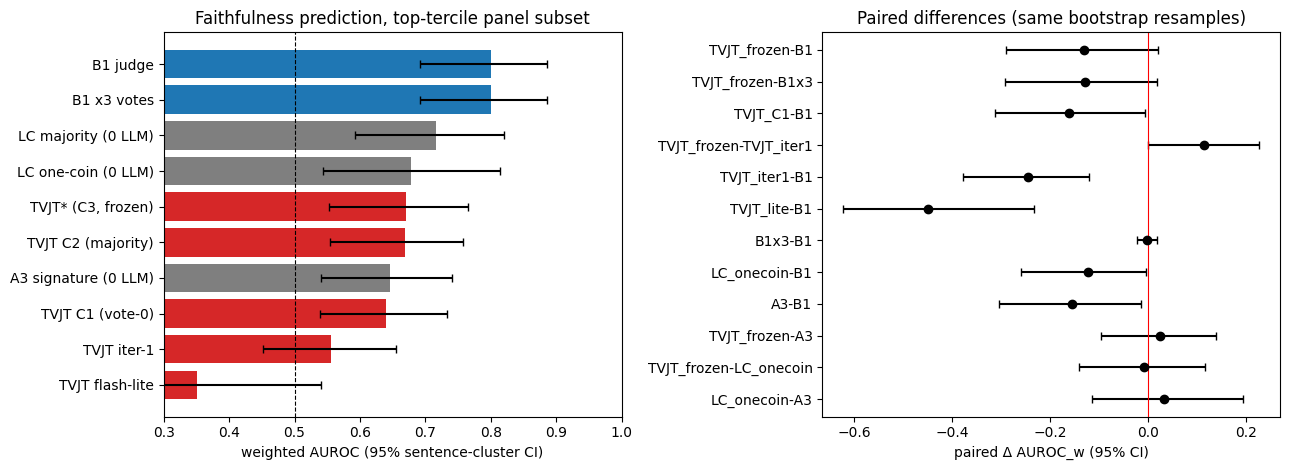

In [16]:
names = {"TVJT_frozen": "TVJT* (C3, frozen)", "TVJT_C1": "TVJT C1 (vote-0)", "TVJT_C2": "TVJT C2 (majority)",
         "B1": "B1 judge", "B1x3": "B1 x3 votes", "TVJT_iter1": "TVJT iter-1", "TVJT_lite": "TVJT flash-lite",
         "LC_onecoin": "LC one-coin (0 LLM)", "LC_maj": "LC majority (0 LLM)", "A3": "A3 signature (0 LLM)"}
tab = pd.DataFrame([{
    "metric": names[m], "AUROC_w": res["all"]["auroc"][m]["point"],
    "CI_lo": res["all"]["auroc"][m]["ci"][0], "CI_hi": res["all"]["auroc"][m]["ci"][1],
    "AUROC_unw": res["all_unweighted"][m], "within_sent_acc": res["within_sentence"][m]["acc"],
} for m in mets]).sort_values("AUROC_w", ascending=False)
print(f"Top-tercile held-out panel subset: n={res['all']['n']} items, {df.sid.nunique()} sentences, N_BOOT={N_BOOT}")
print(tab.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("\nPaired deltas (point, 95% CI):")
for k, v in res["all"]["delta"].items():
    print(f"  {k:<26} {v['point']:+.3f}  [{v['ci'][0]:+.3f}, {v['ci'][1]:+.3f}]")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
t = tab.iloc[::-1]
col = ["#d62728" if "TVJT" in n else "#1f77b4" if "B1" in n else "#7f7f7f" for n in t.metric]
ax[0].barh(t.metric, t.AUROC_w, xerr=[t.AUROC_w - t.CI_lo, t.CI_hi - t.AUROC_w], color=col, capsize=3)
ax[0].axvline(0.5, ls="--", c="k", lw=0.8)
ax[0].set_xlim(0.3, 1.0)
ax[0].set_xlabel("weighted AUROC (95% sentence-cluster CI)")
ax[0].set_title("Faithfulness prediction, top-tercile panel subset")
dl = list(res["all"]["delta"].items())[::-1]
yy = np.arange(len(dl))
pt_ = [v["point"] for _, v in dl]
ax[1].errorbar(pt_, yy, xerr=[[p - v["ci"][0] for p, (_, v) in zip(pt_, dl)],
                              [v["ci"][1] - p for p, (_, v) in zip(pt_, dl)]], fmt="o", c="k", capsize=3)
ax[1].axvline(0, c="r", lw=0.8)
ax[1].set_yticks(yy, [k for k, _ in dl])
ax[1].set_xlabel("paired Δ AUROC_w (95% CI)")
ax[1].set_title("Paired differences (same bootstrap resamples)")
plt.tight_layout()
plt.show()

### Reading the results (97-item top-tercile subset, N_BOOT = 2000)

* **B1 ranks best.** The fixed-prompt judge sees the formula and the sentence together. It reaches AUROC_w ≈ .80, against ≈ .67 for TVJT\*. The subset's paired Δ(TVJT\*−B1) ≈ −.13 points the same way as the artifact's pre-registered full P-top result, −.098 [−.184, −.014], which gave the verdict **REVERSED**. With only 35 sentence clusters, this subset's CI just reaches 0, so the subset alone is inconclusive. The full panel is not.
* **The repair helped TVJT, but not enough.** TVJT\* beats iter-1 TVJT on these items (Δ ≈ +.12). Canonical, deterministic worlds and the 3-vote confidence-weighted protocol make TVJT invariant to reordering, De Morgan and contrapositive rewrites, with 0 false alarms in the full run. Invariance was not the bottleneck. The bottleneck is that "is this sentence true in this toy world?" judgements are noisy for long, heavily conditioned sentences, and those worlds are hard to verbalise faithfully. The cheaper flash-lite judge scores below chance.
* **Within a sentence, TVJT is at chance.** Its within-sentence pairwise accuracy is about .51, against about .77 for B1. The world checks do not separate a faithful candidate from an unfaithful candidate of the same sentence.
* **Error-type naming fails.** TVJT's named error type, the family of its most-violated worlds, is right about 6% of the time on unfaithful items. That is below the majority-class rate (about 27%), in line with the artifact's .077 vs .273.
* **Zero-LLM baselines** (LC latent-class agreement across 9 systems, and the A3 lexical signature) land in the same range as TVJT\* at no LLM cost. None of them reaches B1.

To reproduce the artifact's full numbers (P = 609, P-top = 389, N_BOOT = 2000), run `python method.py --stage analysis` in the artifact workspace.